## Deepfake Detecion Project (Digital Image Processing)

### Authors:
- Huỳnh Anh Nhựt
- Nguyễn Tiến Minh
- Huỳnh Anh Tuấn

### Import thư viện

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import torch
from config import Config
from dataloader import get_dataloaders
from model import get_model
from training import train_model, predict_test
from utilities import load_model, predict_video, plot_history, plot_roc_curve, plot_confusion_matrix, print_classification_report, predict_video_visual, plot_all_splits


c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup model và Dataloader

In [3]:
cnf = Config("efficientnet_b0")

model = get_model(config=cnf)
device = cnf.device

train_loader, val_loader, test_loader = get_dataloaders(cnf)

print(device)

c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cuda


### Dataset

In [ ]:
plot_all_splits(cnf) 

### Tham số huấn luyện

In [3]:
pos_weight = torch.tensor([1.5]).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cnf.Learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.3, patience=1, verbose=True)

c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


### Load model efficentnet_b0

In [4]:
model_eff, optimizer, scheduler, history = load_model("models/efficientnet_b0.pth", model, optimizer, scheduler, device)

model_eff


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

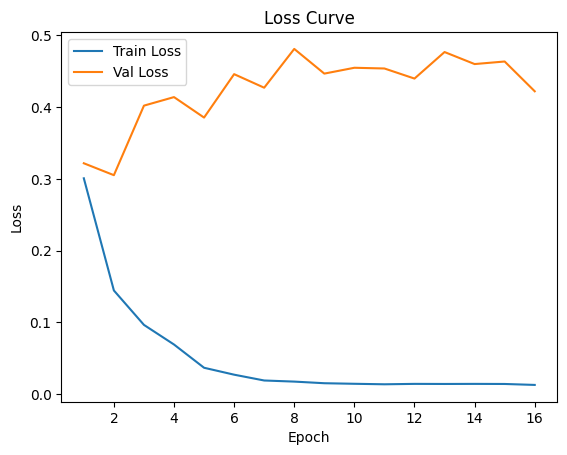

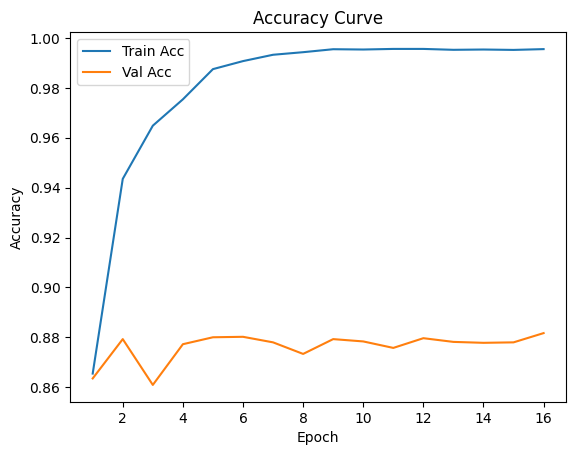

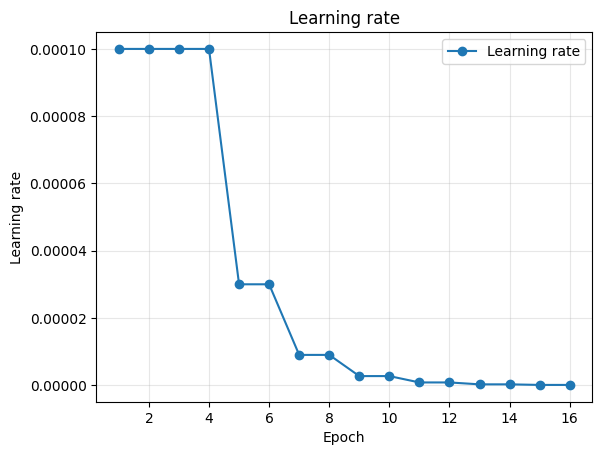

In [5]:
plot_history(history)

### Nhận xét:
- Train loss giảm dần đều nhưng val loss lại có xu hướng tăng lên
- Train accuracy tăng dần đến 1 nhưng val acc chỉ tăng đến gần 0.9
- Khi train với càng nhiều epoch thì model có xu hướng overfitting nhẹ

### Dự đoán trên Test set

In [ ]:
acc, all_preds, all_labels, all_probs = predict_test(model_eff, test_loader, device)

Test Accuracy: 0.883271375464684


### Đánh giá trên từng Frame

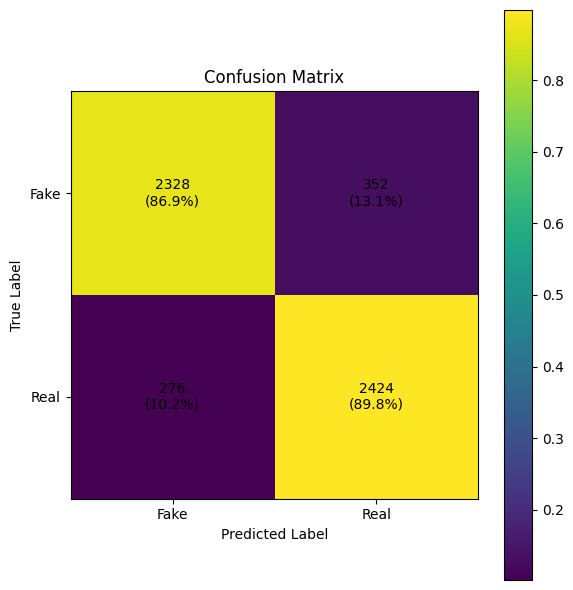

In [8]:
plot_confusion_matrix(all_labels, all_preds)

In [9]:
print_classification_report(all_labels, all_preds)

              precision    recall  f1-score   support

        Fake     0.8940    0.8687    0.8812      2680
        Real     0.8732    0.8978    0.8853      2700

    accuracy                         0.8833      5380
   macro avg     0.8836    0.8832    0.8832      5380
weighted avg     0.8836    0.8833    0.8832      5380



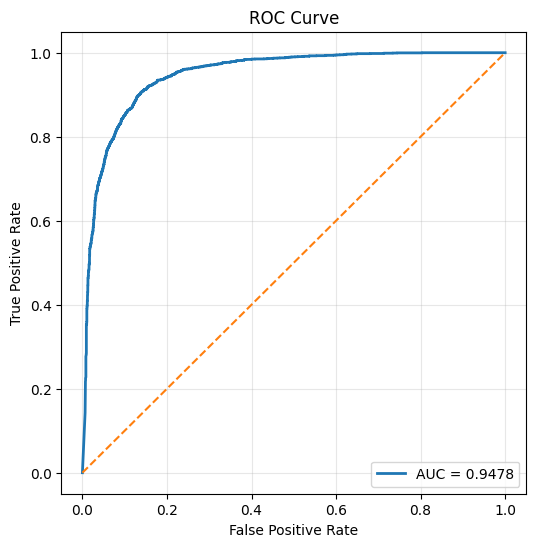

AUC: 0.9478


In [11]:
plot_roc_curve(all_labels, all_probs)